In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os
from os import path

In [2]:
functions = [
    'ackley',
    'sphere',
    'levy',
    'rastrigin'
]

algorithms = [
    'ASHGF',
    'ASGF',
    'GD',
    'SGES', 
    'ASEBO'
]

C:\Users\manen\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:31: RuntimeWarning: Mean of empty slice
C:\Users\manen\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:32: RuntimeWarning: All-NaN axis encountered
C:\Users\manen\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:33: RuntimeWarning: All-NaN axis encountered
C:\Users\manen\AppData\Roaming\Python\Python37\site-packages\numpy\lib\nanfunctions.py:1665: RuntimeWarning: Degrees of freedom <= 0 for slice.
  keepdims=keepdims)
C:\Users\manen\AppData\Roaming\Python\Python37\site-packages\numpy\lib\nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
C:\Users\manen\AppData\Roaming\Python\Python37\site-packages\numpy\core\fromnumeric.py:87: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\manen\AppData\Roaming\Python\Python37\site-packages\numpy\lib\nanfunc

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

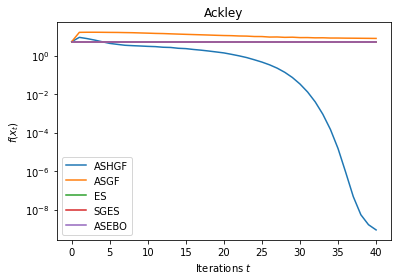

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

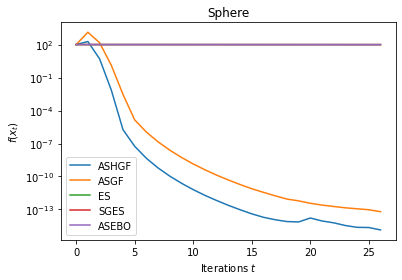

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

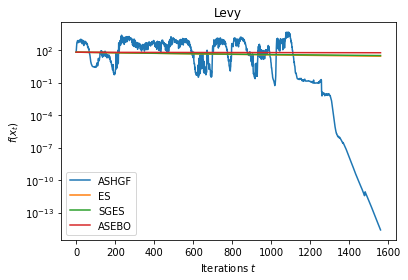

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

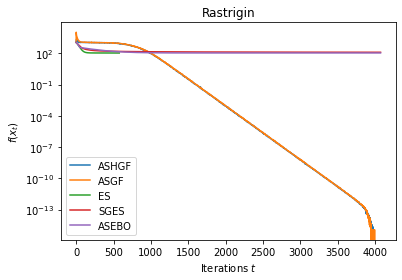

In [3]:
for function in functions:
    mean_descents = {}
    min_descents = {}
    max_descents = {}
    std_plus_descents = {}
    std_minus_descents = {}

    for algorithm in algorithms:
        plt.figure()

        descents = []
        longest_descent = 0
        min_descent = []
        max_descent = []
        mean_descent = []
        std_plus_descent = []
        std_minus_descent = []

        pkl_file = open(
            os.path.join('results', 'stats', algorithm,
                         'descents_{}.pkl'.format(function)), 'rb')
        descents = pickle.load(pkl_file)
        pkl_file.close()

        min_num_it = int(np.max([len(best) for best in descents]))

        for i in range(min_num_it):
            values = [
                best[i] if i < len(best) else np.nan for best in descents
            ]
            mean_value = np.nanmean(values)
            min_value = np.nanmin(values)
            max_value = np.nanmax(values)
            std_value = np.nanstd(values)

            min_descent.append(min_value)
            max_descent.append(max_value)
            mean_descent.append(mean_value)
            std_plus_descent.append(mean_value + std_value)
            std_minus_descent.append(max([min_value, mean_value - std_value]))

        mean_descents[algorithm] = mean_descent
        min_descents[algorithm] = min_descent
        max_descents[algorithm] = max_descent
        std_plus_descents[algorithm] = std_plus_descent
        std_minus_descents[algorithm] = std_minus_descent

    min_len = 0
    last_temp = 1000000000000
    name = ''
    for algorithm in algorithms:
        last = mean_descents[algorithm][-1]
        if last < last_temp:
            last_temp = last
            name = algorithm
    min_len = len(mean_descents[name])

    if function != 'levy':
        for algorithm in algorithms:
            if algorithm == 'GD':
                plt.plot(mean_descents[algorithm][:min_len], label='ES')
            else:
                plt.plot(mean_descents[algorithm][:min_len], label=algorithm)

        plt.legend()
        plt.yscale('log')
        plt.legend()
        title = function.title()
        plt.title(title)
        plt.xlabel(r'Iterations $t$')
        plt.ylabel(r'$f(x_t)$')
    else:
        for algorithm in algorithms:
            if algorithm != 'ASGF':
                if algorithm == 'GD':
                    plt.plot(mean_descents[algorithm][:min_len], label='ES')
                else:
                    plt.plot(mean_descents[algorithm][:min_len],
                             label=algorithm)

        plt.legend()
        plt.yscale('log')
        plt.legend()
        title = function.title()
        plt.title(title)
        plt.xlabel(r'Iterations $t$')
        plt.ylabel(r'$f(x_t)$')
    plt.savefig(os.path.join('results', 'stats_plots',
                             '{}_convergence_mean.png'.format(function)),
                dpi=600)

In [10]:
pkl_file = open(
    os.path.join('stats', 'ASHGF',
                    'descents_{}.pkl'.format('sphere')), 'rb')
descents = pickle.load(pkl_file)
pkl_file.close()

x = descents[0][0]

pkl_file = open(
    os.path.join('stats', 'ASEBO', 'descents_{}.pkl'.format('sphere')), 'rb')
descents = pickle.load(pkl_file)
pkl_file.close()

for descent in descents:
    if descent[0] != x:
        print('holy schmoly')